In [90]:
using JLD2, Plots

using ArgParse
using Dates
# using JLD2
using Printf

using StatsBase
using Graphs
using SimpleWeightedGraphs
using GraphsMatching
using SpecialFunctions


In [62]:
const ROOT = normpath(joinpath(@__DIR__, ".."))

include(joinpath(ROOT, "src", "circuits.jl"))
include(joinpath(ROOT, "src", "local.jl"))
include(joinpath(ROOT, "src", "main.jl"))
include(joinpath(ROOT, "src", "mwpm.jl"))

track_domains (generic function with 1 method)

In [67]:
L = 8
T = 2L
p = 0.1
q = 0.1
c = 0.1
samples = 10
algo = IsingML(q,c)
M1s, M2s, E1s, E2s, instant_failures, cumulative_failures, Ms_hist, Es_hist = sample(L, T, p, q, algo, samples)

([0.0, 0.0421875, 0.0484375, 0.0859375, 0.0828125, 0.06875, 0.0796875, 0.0796875, 0.040625, 0.046875, 0.0609375, 0.0453125, 0.1046875, 0.09375, 0.134375, 0.11875, 0.1671875], [0.0, 0.0021728515625, 0.0032958984375, 0.0085205078125, 0.0093017578125, 0.00556640625, 0.0086669921875, 0.0118896484375, 0.00224609375, 0.003271484375, 0.0060302734375, 0.0039306640625, 0.0232177734375, 0.016064453125, 0.03310546875, 0.0302734375, 0.0495361328125], [112.0, 94.6, 94.8, 83.0, 84.8, 88.8, 86.2, 88.8, 96.0, 94.2, 91.4, 97.6, 85.4, 88.8, 85.0, 86.6, 86.8], [12544.0, 9016.4, 9106.4, 6956.4, 7364.0, 7974.4, 7655.6, 8143.2, 9285.6, 9006.8, 8535.6, 9653.6, 7562.0, 8047.2, 7388.4, 7760.4, 7620.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Int32[10 0 1; 0 3 0; … ; 0 0 0; 0 0 0], Int32[0 0 0; 0 0 0; … ; 0 0 0; 10 0 1])

In [68]:
Es_hist

113×3 Matrix{Int32}:
  0  0  0
  0  0  0
  0  0  0
  0  0  0
  0  0  0
  0  0  0
  0  0  0
  0  0  0
  0  0  0
  0  0  0
  ⋮     
  0  0  0
  0  1  0
  0  1  0
  0  1  0
  0  2  0
  0  1  0
  0  0  0
  0  0  0
 10  0  1

In [2]:
# load_results.jl
#
# Usage: include("load_results.jl"), then call load_results(dirs...)
#
# Example:
#   results = load_results("output/MV_L80_sweep", "output/IsingML_L16_sweep")
#
# Returns a single Dict{NTuple{7,Any}, NamedTuple} merging all collated_results.jld2 files.
# Keys are (algo, L, T, p, q, c).

using JLD2

function load_results(dirs::AbstractString...)
    results = Dict{NTuple{6,Any}, NamedTuple}()

    for dir in dirs
        fpath = joinpath(dir, "collated_results.jld2")
        if !isfile(fpath)
            @warn "No collated_results.jld2 found in $dir, skipping"
            continue
        end
        loaded = jldopen(fpath, "r") do f
            f["results"]
        end
        for ((tag, algo, L, T, p, q, c), v) in loaded
            results[(algo, L, T, p, q, c)] = v
        end
    end

    return results
end

load_results (generic function with 1 method)

In [3]:
results = load_results("../osg_output/IsingML_L8_sweep", "../vt_output/IsingML_L8_sweep")

Dict{NTuple{6, Any}, NamedTuple} with 2541 entries:
  ("IsingML", 8, 160, 0.4, 0.05, 0.9)   => (M1s = [0.0, 0.0922188, 0.155688, 0.…
  ("IsingML", 8, 160, 0.05, 0.15, 0.15) => (M1s = [0.0, 0.0327047, 0.0516406, 0…
  ("IsingML", 8, 160, 0.2, 0.25, 0.15)  => (M1s = [0.0, 0.23857, 0.365119, 0.42…
  ("IsingML", 8, 160, 0.05, 0.5, 0.05)  => (M1s = [0.0, 0.319666, 0.431005, 0.4…
  ("IsingML", 8, 160, 0.1, 0.1, 0.15)   => (M1s = [0.0, 0.0417812, 0.0602141, 0…
  ("IsingML", 8, 160, 0.25, 0.3, 0.9)   => (M1s = [0.0, 0.415641, 0.477438, 0.4…
  ("IsingML", 8, 160, 0.35, 0.35, 0.85) => (M1s = [0.0, 0.454, 0.493563, 0.4971…
  ("IsingML", 8, 160, 0.25, 0.45, 0.15) => (M1s = [0.0, 0.392123, 0.477155, 0.4…
  ("IsingML", 8, 160, 0.25, 0.05, 0.55) => (M1s = [0.0, 0.0230469, 0.0255156, 0…
  ("IsingML", 8, 160, 0.15, 0.1, 0.25)  => (M1s = [0.0, 0.0683, 0.0963594, 0.11…
  ("IsingML", 8, 160, 0.4, 0.2, 0.35)   => (M1s = [0.0, 0.408194, 0.480956, 0.4…
  ("IsingML", 8, 160, 0.5, 0.1, 0.8)    => (M1s = [0.0, 0

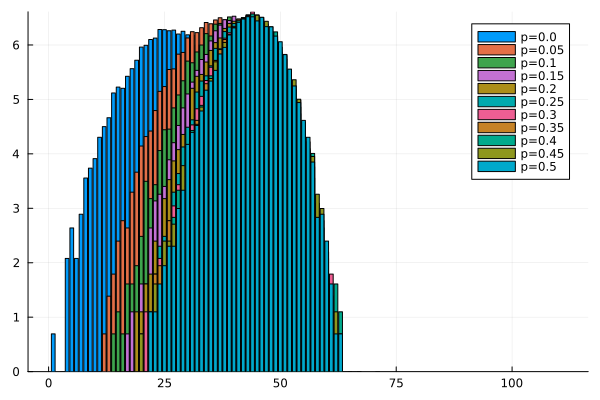

In [158]:
algo = "IsingML"
L = 8
T = 20L
p = 0.4
q = 0.3
c = 0.1

plt = plot()

for p in 0.0:0.05:0.5
    bar!(plt, log.(reverse(results[(algo, L, T, p, q, c)][:Es_hist][:,10][1:1:end])),label="p=$p", legend=:topright)
end
plt

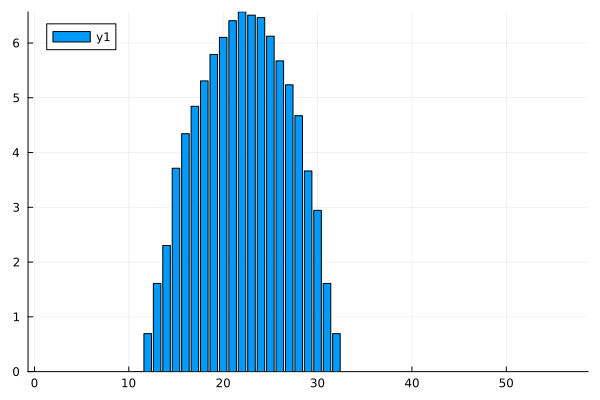

In [160]:
algo = "IsingML"
L = 8
T = 20L
p = 0.4
q = 0.3
c = 0.05

plt = plot()

bar(log.(reverse(results[(algo, L, T, p, q, c)][:Es_hist][:,10][1:2:end])))

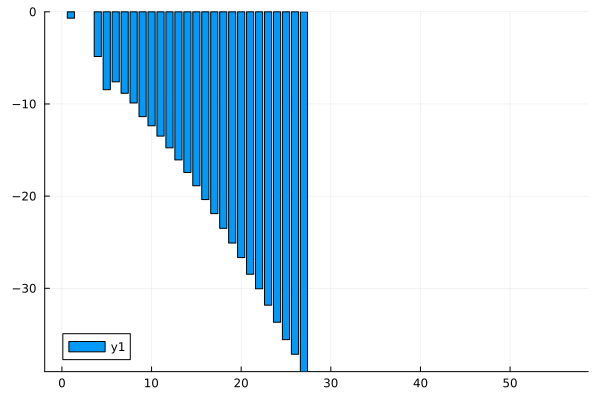

In [188]:
algo = "IsingML"
L = 8
T = 20L
p = 0.2
q = 0.2
c = 0.05

plt = plot()

bar(log.(reverse(results[(algo, L, T, p, q, c)][:Es_hist][:,10][1:2:end])) .- log.(counts)[1:57])

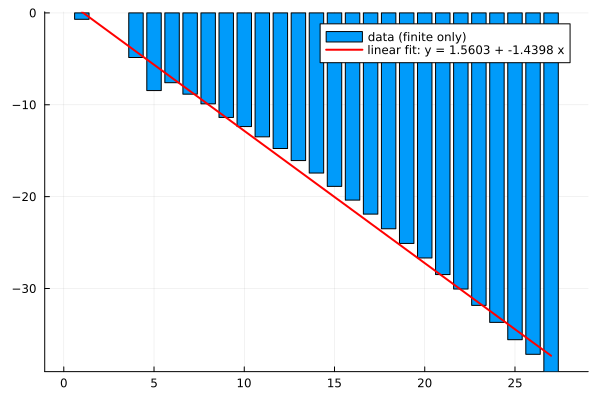

In [189]:
# reuse variables from the cell above: algo, L, T, p, q, c

y_raw = log.(reverse(results[(algo, L, T, p, q, c)][:Es_hist][:,10][1:2:end])) .- log.(counts)[1:57]
x_raw = collect(1:length(y_raw))

# remove Inf/-Inf/NaN before fitting
mask = isfinite.(y_raw)
x = Float64.(x_raw[mask])
y = y_raw[mask]

# linear least-squares fit: y ≈ β0 + β1*x
X = hcat(ones(length(x)), x)
β = X \ y
yfit = X * β

plt = bar(x, y, label="data (finite only)", legend=:topright)
plot!(plt, x, yfit, color=:red, lw=2, label=@sprintf("linear fit: y = %.4f + %.4f x", β[1], β[2]))
plt

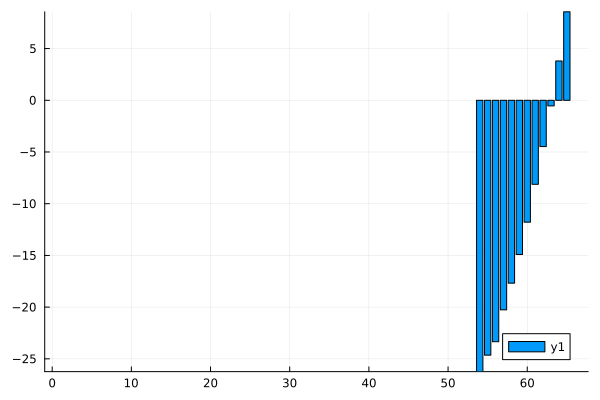

In [190]:
algo = "IsingML"
L = 8
T = 20L
p = 0.05
q = 0.05
c = 0.05

plt = plot()

bar(log.(reverse(results[(algo, L, T, p, q, c)][:Ms_hist][:,10])) .- [log_binom(L^2, k) for k in 0:(L^2)])

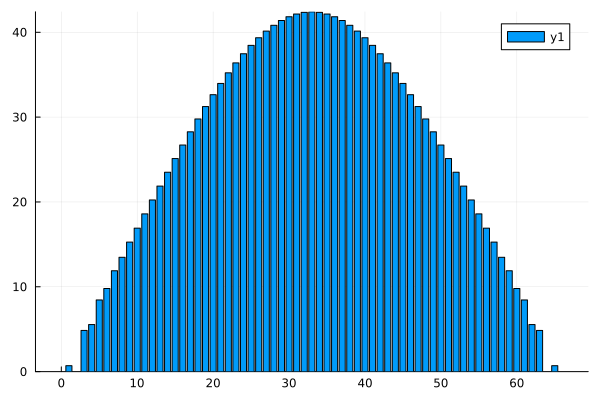

In [167]:
bar(log.(counts))

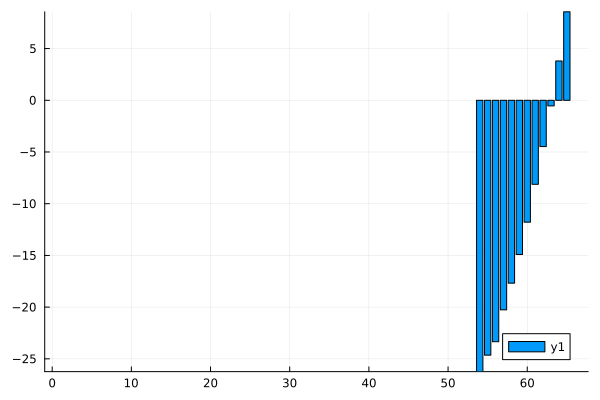

In [129]:
algo = "IsingML"
L = 8
T = 20L
p = 0.05
q = 0.05
c = 0.05

plt = plot()

bar(log.(reverse(results[(algo, L, T, p, q, c)][:Ms_hist][:,10])) .- [log_binom(L^2, k) for k in 0:(L^2)])

In [115]:
function sample_noise(L::Int, p::Float64)
    ρ = initialstate(L)
    Ms = 0.0
    Es = 0.0

    ρ = noiselayer(ρ, p)
    checks = measure(ρ, q)
    Ms = magnetization(ρ)
    Es = energy(ρ)

    return Ms, Es
end

function sample_noise(L::Int, p::Float64, samples::Int)
    # histogram bin counts:
    #   M = k/L² for k in 0:L²  =>  n_M_bins = L²+1
    #   E is even integer in [-2L(L-1), 2L(L-1)]  =>  n_E_bins = 2L(L-1)+1
    # bin index helpers (1-based):
    #   M_bin(M) = round(Int, M * L²) + 1
    #   E_bin(E) = round(Int, E) ÷ 2 + L*(L-1) + 1
    n_M_bins = L^2 + 1
    n_E_bins = 2*L*(L-1) + 1

    # (1) averaged time series
    M1s = 0.0
    M2s = 0.0
    E1s = 0.0
    E2s = 0.0

    # (2) histograms at each snapshot: shape (n_bins × n_snapshots)
    Ms_hist = zeros(Int32, n_M_bins)
    Es_hist = zeros(Int32, n_E_bins)

    # (3) averaged instant failure rate at each timestep
    instant_failures    = 0.0

    # (4) averaged cumulative failure rate at each timestep
    cumulative_failures = 0.0

    for i in 1:samples
        Ms, Es = sample_noise(L, p)

        # (1)
        M1s += Ms
        M2s += Ms.^2
        E1s += Es
        E2s += Es.^2

        # (2)
        Ms_hist[round(Int, Ms * L^2) + 1] += one(Int32)
        Es_hist[round(Int, Es) ÷ 2 + L*(L-1) + 1] += one(Int32)


        # (3)
        instant_failures += Ms .> 0.5

        # (4)
        ever_failed = false
        ever_failed |= Ms > 0.5
        cumulative_failures += ever_failed
    end

    M1s                /= samples
    M2s                /= samples
    E1s                /= samples
    E2s                /= samples
    instant_failures   /= samples
    cumulative_failures /= samples

    return M1s, M2s, E1s, E2s, instant_failures, cumulative_failures, Ms_hist, Es_hist
end

sample_noise (generic function with 2 methods)

In [123]:
L = 8
p = 0.1
samples = 10000
M1s, M2s, E1s, E2s, instant_failures, cumulative_failures, Ms_hist, Es_hist = sample_noise(L, p, samples)

(0.0998453125, 0.0113877685546875, 71.7164, 5343.5464, 0.0, 0.0, Int32[4, 90, 297, 667, 1172, 1551, 1672, 1480, 1197, 829  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], Int32[0, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  121, 121, 148, 77, 14, 54, 37, 3, 0, 4])

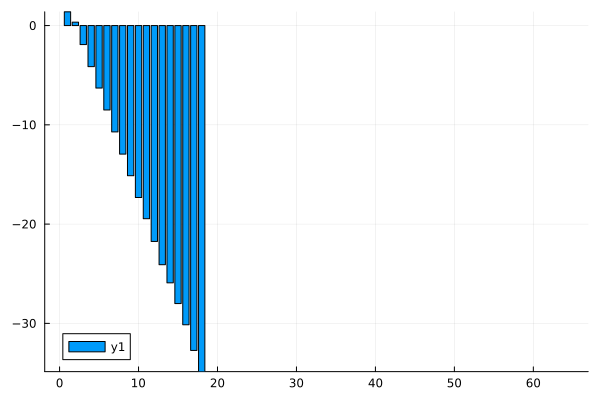

In [127]:
bar(log.(Ms_hist) .- [log_binom(L^2, k) for k in 0:(L^2)])

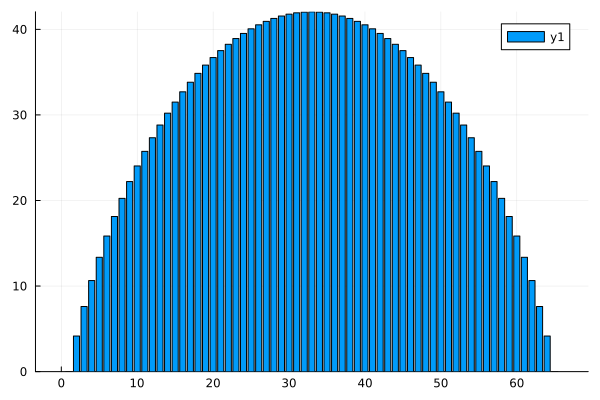

In [92]:
algo = "IsingML"
L = 8
T = 20L
p = 0.1
q = 0.05
c = 0.0

log_binom(n, k) = lgamma(n+1) - lgamma(k+1) - lgamma(n-k+1)


plt = plot()

bar([log_binom(L^2, k) for k in 0:(L^2)])

In [83]:
reverse(results[(algo, L, T, p, q, c)][:Es_hist][:,10][1:2:end])

57-element Vector{Int32}:
 3149
  190
 1710
  634
  660
  347
  285
  159
   77
   38
    ⋮
    0
    0
    0
    0
    0
    0
    0
    0
    0

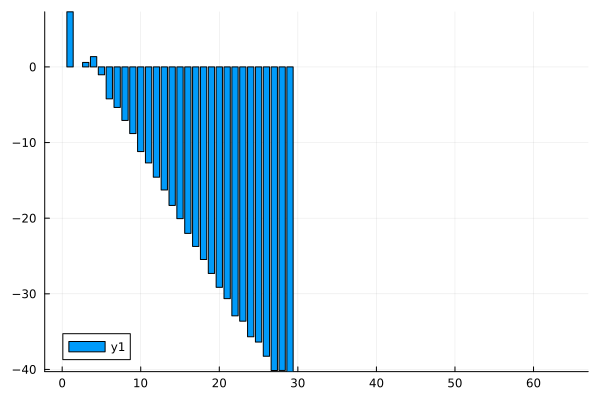

In [33]:
algo = "IsingML"
L = 8
T = 20L
p = 0.1
q = 0.05
c = 0.0

plt = plot()

bar(log.(reverse(results[(algo, L, T, p, q, c)][:Es_hist][:,10][49:end])) .- log.(counts))

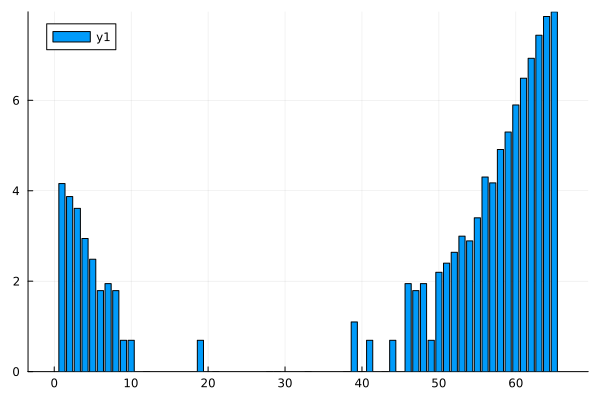

In [35]:
algo = "IsingML"
L = 8
T = 20L
p = 0.1
q = 0.05
c = 0.0

plt = plot()

bar(log.(reverse(results[(algo, L, T, p, q, c)][:Ms_hist][:,10])))

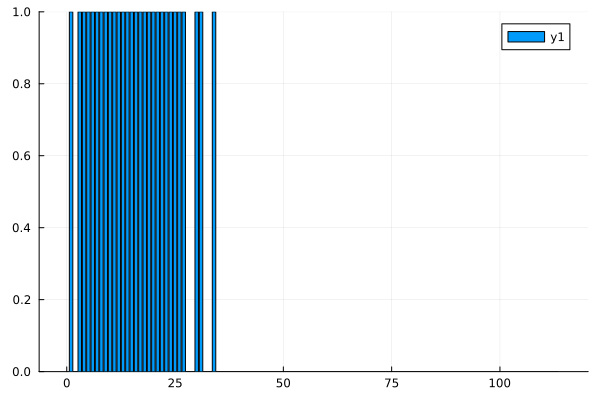

In [42]:
algo = "IsingML"
L = 8
T = 20L
p = 0.1
q = 0.05
c = 0.0

plt = plot()

bar(reverse(results[(algo, L, T, p, q, c)][:Es_hist][:,17]) .> 0)

In [46]:
L = 8
ρ = [0 1 0 1 0 1 0 1
     1 0 1 0 1 0 1 0
     0 1 0 1 0 1 0 1
     1 0 1 0 1 0 1 0
     0 1 0 1 0 1 0 1
     1 0 1 0 1 0 1 0
     0 1 0 1 0 1 0 1
     1 0 1 0 1 0 1 0]

E = energy(ρ)

-112

In [47]:
round(Int, E) ÷ 2 + L*(L-1) + 1

1

In [54]:
L = 8
ρ = [0 0 0 0 0 0 0 0
     0 0 0 0 0 0 0 0
     0 0 0 0 0 0 0 0
     0 0 0 1 1 0 0 0
     0 0 0 0 0 0 0 0
     0 0 0 0 0 0 0 0
     0 0 0 0 0 0 0 0
     0 0 0 0 0 0 0 0]

E = energy(ρ)
round(Int, E) ÷ 2 + L*(L-1) + 1

107

In [69]:
counts

65-element Vector{Int64}:
        2
        0
      128
      256
     4672
    17920
   145408
   712960
  4274576
 22128384
        ⋮
  4274576
   712960
   145408
    17920
     4672
      256
      128
        0
        2

In [70]:
repeat(counts, inner=2)

130-element Vector{Int64}:
    2
    2
    0
    0
  128
  128
  256
  256
 4672
 4672
    ⋮
 4672
  256
  256
  128
  128
    0
    0
    2
    2

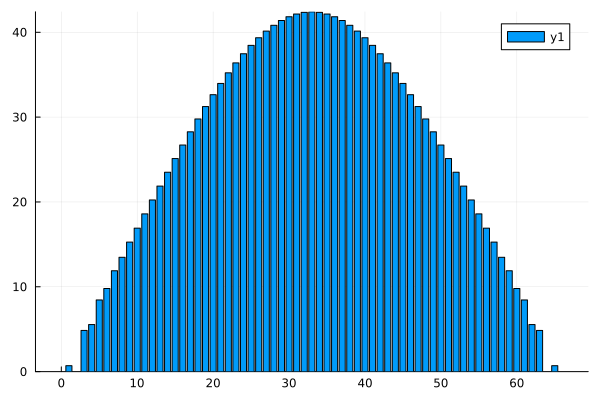

In [30]:
bar(log.(counts))

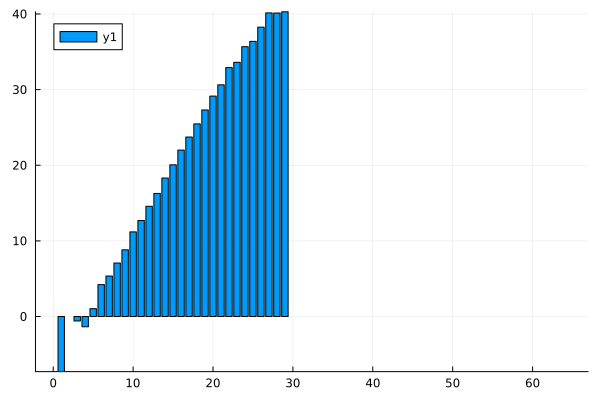

In [23]:
algo = "IsingML"
L = 8
T = 20L
p = 0.1
q = 0.05
c = 0.0

plt = plot()

bar(-log.(reverse(results[(algo, L, T, p, q, c)][:Es_hist][:,10][49:end]) ./ counts))

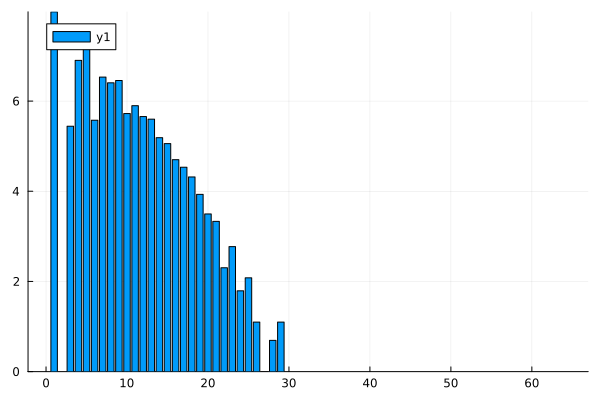

In [25]:
bar(log.(reverse(results[(algo, L, T, p, q, c)][:Es_hist][:,10][49:end])))

In [8]:
counts = [2,0,128,256,4672,17920,145408,712960,4274576,22128384,118551552,610683392,3150447680,16043381504,80748258688,396915938304,1887270677624,8582140066816,36967268348032,149536933509376,564033837424064,1971511029384704,6350698012553216,18752030727310592,50483110303426544,123229776338119424,271209458049836032,535138987032308224,941564975390477248,1469940812209435392,2027486077172296064,2462494093546483712,2627978003957146636,2462494093546483712,2027486077172296064,1469940812209435392,941564975390477248,535138987032308224,271209458049836032,123229776338119424,50483110303426544,18752030727310592,6350698012553216,1971511029384704,564033837424064,149536933509376,36967268348032,8582140066816,1887270677624,396915938304,80748258688,16043381504,3150447680,610683392,118551552,22128384,4274576,712960,145408,17920,4672,256,128,0,2]

65-element Vector{Int64}:
        2
        0
      128
      256
     4672
    17920
   145408
   712960
  4274576
 22128384
        ⋮
  4274576
   712960
   145408
    17920
     4672
      256
      128
        0
        2

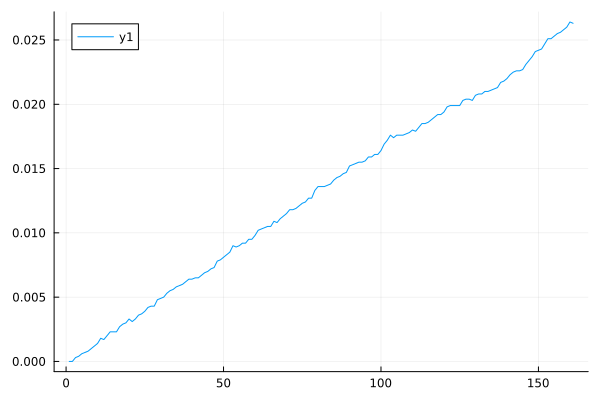

In [67]:
algo = "IsingML"
L = 8
T = 20L
p = 0.1
q = 0.05
c = 0.1

plot(results[(algo, L, T, p, q, c)][:instant_failures])

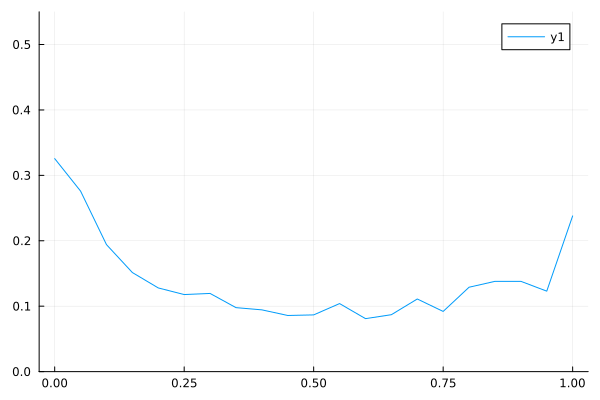

In [68]:
algo = "IsingML"
L = 8
T = 20L
p = 0.15
q = 0.05

plt = plot()

cs = 0.0:0.05:1.0
ms = [results[(algo, L, T, p, q, c)][:instant_failures][end] for c in cs]
plot!(plt, cs, ms, ylim=(0, 0.55))

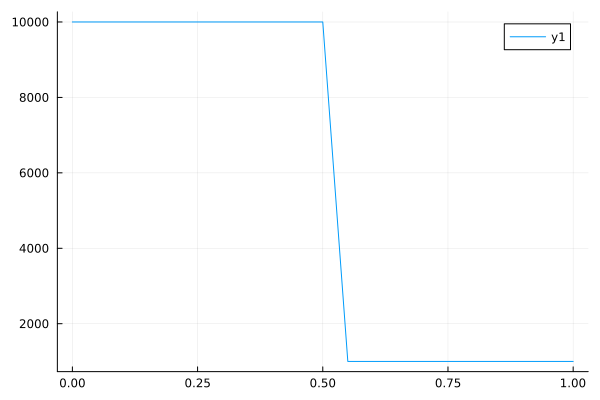

In [42]:
algo = "IsingML"
L = 8
T = 20L
p = 0.1
q = 0.05

plt = plot()

cs = 0.0:0.05:1.0
ms = [results[(algo, L, T, p, q, c)][:total_samples][end] for c in cs]
plot!(plt, cs, ms)

In [63]:
algo = "IsingML"
L = 8
T = 20L
p = 0.1
q = 0.05

plt = plot()

cs = 0.0:0.05:1.0
ms = [results[(algo, L, T, p, q, c)][:x][end] for c in cs]
plot!(plt, cs, ms)

FieldError: FieldError: type NamedTuple has no field `x`, available fields: `M1s`, `M2s`, `E1s`, `E2s`, `instant_failures`, `cumulative_failures`, `Ms_hist`, `Es_hist`, `total_samples`, `total_time`